In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./.saved_models/FinalSentimentModel//"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    problem_type="multi_label_classification"
)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"device: {device}")

sentimentLabels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

with open(model_path + "/optimal_thresholds.json") as f:
    _thresh_dict = json.load(f)
optimal_thresholds = np.array([_thresh_dict[name] for name in sentimentLabels])

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2301.30it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


device: mps


In [2]:
def predict_emotions(texts, batch_size=16):
    all_predictions = []
    for i in range(0, len(texts), batch_size):
        inputs = tokenizer(
            texts[i:i + batch_size],
            padding=True, truncation=True, max_length=128, return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            probs = torch.sigmoid(model(**inputs).logits).cpu().numpy()
        for prob in probs:
            preds = [sentimentLabels[j] for j, t in enumerate(optimal_thresholds) if prob[j] >= t]
            all_predictions.append(preds if preds else ['neutral'])
    return all_predictions

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

political_model_name = "bucketresearch/politicalBiasBERT"
political_tokenizer = AutoTokenizer.from_pretrained(political_model_name)
political_model = AutoModelForSequenceClassification.from_pretrained(
    political_model_name, num_labels=2, ignore_mismatched_sizes=True
)

political_weights_path = ".saved_models/politicalBiasBERT_finetuned_best.pt"
political_model.load_state_dict(torch.load(political_weights_path, map_location=device))
political_model = political_model.to(device)
political_model.eval()

political_label_map = {0: 'Liberal', 1: 'Conservative'}
print(f"political model loaded on {device}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2317.62it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: bucketresearch/politicalBiasBERT
Key                          | Status     |                                                                                       
-----------------------------+------------+---------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                       
classifier.weight            | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arc

political model loaded on mps


In [4]:
import pickle

topic_model_path = ".saved_models/K-means_bertopic_model_data.pkl"
with open(topic_model_path, 'rb') as f:
    topic_model_data = pickle.load(f)

topic_model = topic_model_data['topic_model']
topic_labels = topic_model_data['human_labels']  # dict: {topic_id: label}

print(f"BERTopic model loaded: {len(topic_labels)} topics")

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


BERTopic model loaded: 33 topics


In [5]:
def predict_political_bias(texts, batch_size=16):
    all_predictions = []
    for i in range(0, len(texts), batch_size):
        inputs = political_tokenizer(
            texts[i:i + batch_size],
            padding=True, truncation=True, max_length=512, return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            preds = torch.argmax(political_model(**inputs).logits, dim=1).cpu().numpy()
        all_predictions.extend([political_label_map[p] for p in preds])
    return all_predictions

In [6]:
def predict_topics(texts):
    topics, _ = topic_model.transform(texts)
    return topics

In [7]:
import ast

test_df = pd.read_csv("Test Dataset Creation/last_combined_all_reddit_comments.csv")

def parse_emotion_list(s):
    try:
        return ast.literal_eval(s)
    except:
        return ['neutral']

test_df['ground_truth_emotions'] = test_df['predicted_emotion'].apply(parse_emotion_list)
test_df['combined_text'] = test_df['post_title'].fillna('') + ' ' + test_df['comment_body'].fillna('')

print(f"{len(test_df)} samples loaded")

5960 samples loaded


In [8]:
import time

test_texts = test_df['combined_text'].tolist()

t0 = time.time()
test_df['model_predicted_emotions'] = predict_emotions(test_texts, batch_size=16)
sentiment_time = time.time() - t0

t0 = time.time()
test_df['model_predicted_political'] = predict_political_bias(test_texts, batch_size=16)
political_time = time.time() - t0

t0 = time.time()
test_df['model_predicted_topic'] = predict_topics(test_texts)
topic_time = time.time() - t0

n = len(test_texts)
latency_metrics = {
    'sentiment': {'total': sentiment_time, 'per_sample': sentiment_time / n * 1000},
    'political':  {'total': political_time,  'per_sample': political_time  / n * 1000},
    'topic':      {'total': topic_time,      'per_sample': topic_time      / n * 1000},
}

print(f"sentiment: {sentiment_time:.2f}s | political: {political_time:.2f}s | topic: {topic_time:.2f}s")

# quick sanity check on a few samples
for i in range(3):
    row = test_df.iloc[i]
    print(f"\n[{row['subreddit']}] {row['comment_body'][:80]}")
    print(f"  emotions: {row['model_predicted_emotions']}")
    print(f"  political: {row['model_predicted_political']}  topic: {row['model_predicted_topic']}")

Batches: 100%|██████████| 187/187 [00:09<00:00, 18.80it/s]


sentiment: 34.30s | political: 62.81s | topic: 12.50s

[Liberal] Fuck ICE.
  emotions: ['anger', 'neutral']
  political: Conservative  topic: 0

[Liberal] Here’s a better article from Daily Beast including quotes that Trump is looking 
  emotions: ['neutral']
  political: Conservative  topic: 3

[Liberal] They’re all puppets, it doesn’t actually matter who is in charge
  emotions: ['neutral']
  political: Conservative  topic: 5


In [9]:
results_df = test_df[[
    'subreddit', 'post_title', 'comment_body',
    'ground_truth_emotions', 'predicted_topic',
    'model_predicted_emotions', 'model_predicted_political', 'model_predicted_topic'
]].copy()

results_df['ground_truth_emotions'] = results_df['ground_truth_emotions'].apply(str)
results_df['model_predicted_emotions'] = results_df['model_predicted_emotions'].apply(str)

results_df.to_csv("integrated_pipeline_results.csv", index=False)
print("saved integrated_pipeline_results.csv")

saved integrated_pipeline_results.csv


hamming loss:    0.0857
precision:       0.2995
recall:          0.2967
f1 (samples):    0.2820
macro f1:        0.2381
exact match:     0.1138  (678/5960)

                precision    recall  f1-score   support

    admiration       0.21      0.43      0.29        74
     amusement       0.74      0.21      0.32       606
         anger       0.76      0.18      0.29      1314
     annoyance       0.30      0.24      0.27      1155
      approval       0.42      0.25      0.31       841
        caring       0.24      0.62      0.34         8
     confusion       0.29      0.31      0.30       143
     curiosity       0.27      0.56      0.36       312
        desire       0.36      0.08      0.13       112
disappointment       0.17      0.40      0.24       200
   disapproval       0.72      0.08      0.14      2761
       disgust       0.86      0.04      0.07       781
 embarrassment       0.07      0.50      0.12         4
    excitement       0.16      0.11      0.13        44
  

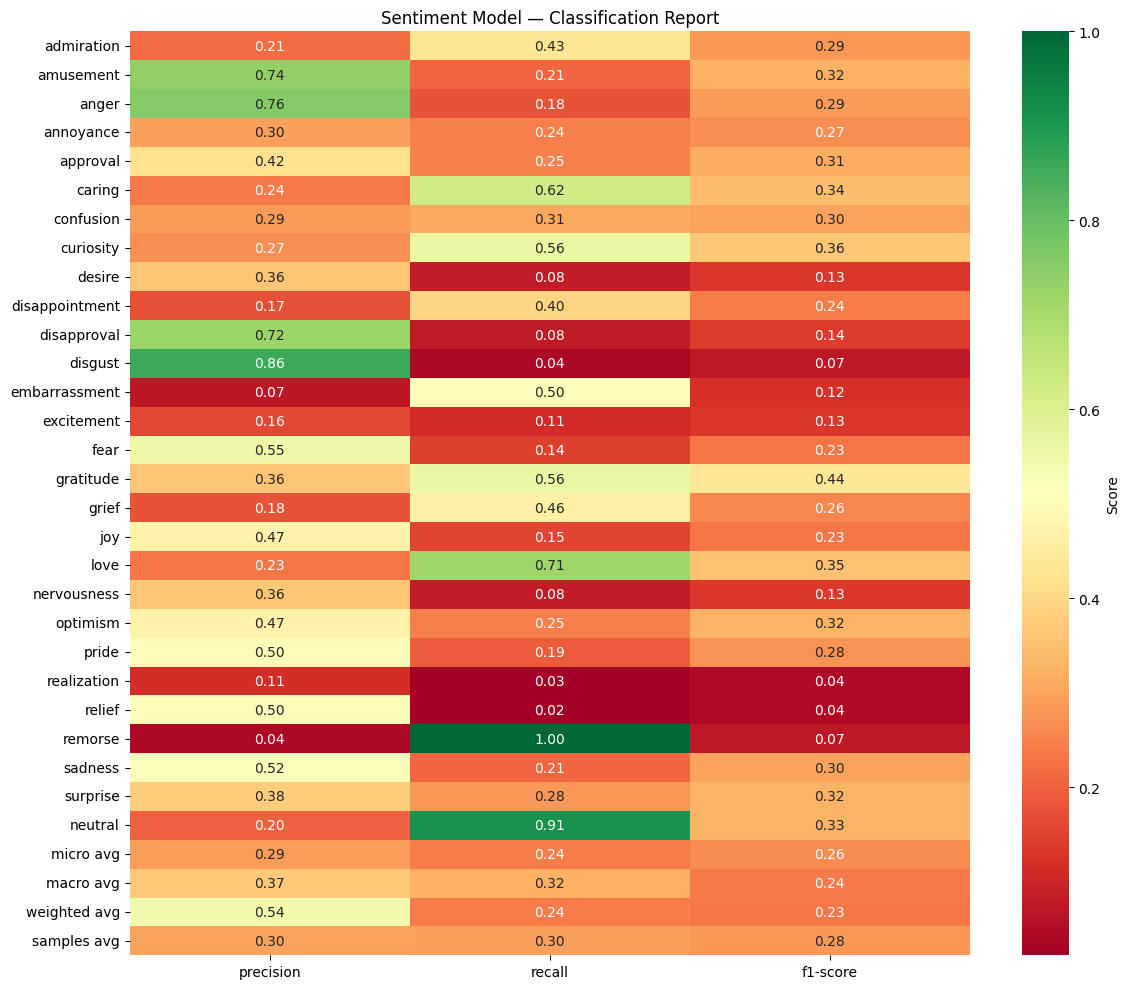


emotion              ground truth  predicted
---------------------------------------------
admiration                     74        150
amusement                     606        170
anger                        1314        307
annoyance                    1155        951
approval                      841        497
caring                          8         21
confusion                     143        153
curiosity                     312        653
desire                        112         25
disappointment                200        454
disapproval                  2761        292
disgust                       781         35
embarrassment                   4         29
excitement                     44         32
fear                          249         65
gratitude                      50         78
grief                          13         34
joy                           118         38
love                           14         43
nervousness                    49         11
optimism

In [10]:
from sklearn.metrics import precision_recall_fscore_support, hamming_loss, classification_report, f1_score
from collections import Counter

def emotions_to_binary(emotion_lists, all_labels):
    mat = np.zeros((len(emotion_lists), len(all_labels)))
    for i, emotions in enumerate(emotion_lists):
        for e in emotions:
            if e in all_labels:
                mat[i, all_labels.index(e)] = 1
    return mat

y_true = emotions_to_binary(test_df['ground_truth_emotions'].tolist(), sentimentLabels)
y_pred = emotions_to_binary(test_df['model_predicted_emotions'].tolist(), sentimentLabels)

hamming = hamming_loss(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='samples', zero_division=0)
sentiment_macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

exact_matches = sum(
    1 for i in range(len(test_df))
    if set(test_df.iloc[i]['ground_truth_emotions']) == set(test_df.iloc[i]['model_predicted_emotions'])
)
exact_match = exact_match_accuracy = exact_matches / len(test_df)

print(f"hamming loss:    {hamming:.4f}")
print(f"precision:       {precision:.4f}")
print(f"recall:          {recall:.4f}")
print(f"f1 (samples):    {f1:.4f}")
print(f"macro f1:        {sentiment_macro_f1:.4f}")
print(f"exact match:     {exact_match_accuracy:.4f}  ({exact_matches}/{len(test_df)})")

print()
print(classification_report(y_true, y_pred, target_names=sentimentLabels, zero_division=0))

report_dict = classification_report(y_true, y_pred, target_names=sentimentLabels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
plt.figure(figsize=(12, 10))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', cbar_kws={'label': 'Score'})
plt.title("Sentiment Model — Classification Report")
plt.tight_layout()
plt.show()

# emotion count comparison
gt_counts = Counter(e for emotions in test_df['ground_truth_emotions'] for e in emotions)
pred_counts = Counter(e for emotions in test_df['model_predicted_emotions'] for e in emotions)
print(f"\n{'emotion':<20} {'ground truth':>12} {'predicted':>10}")
print("-" * 45)
for e in sentimentLabels:
    print(f"{e:<20} {gt_counts.get(e,0):>12} {pred_counts.get(e,0):>10}")

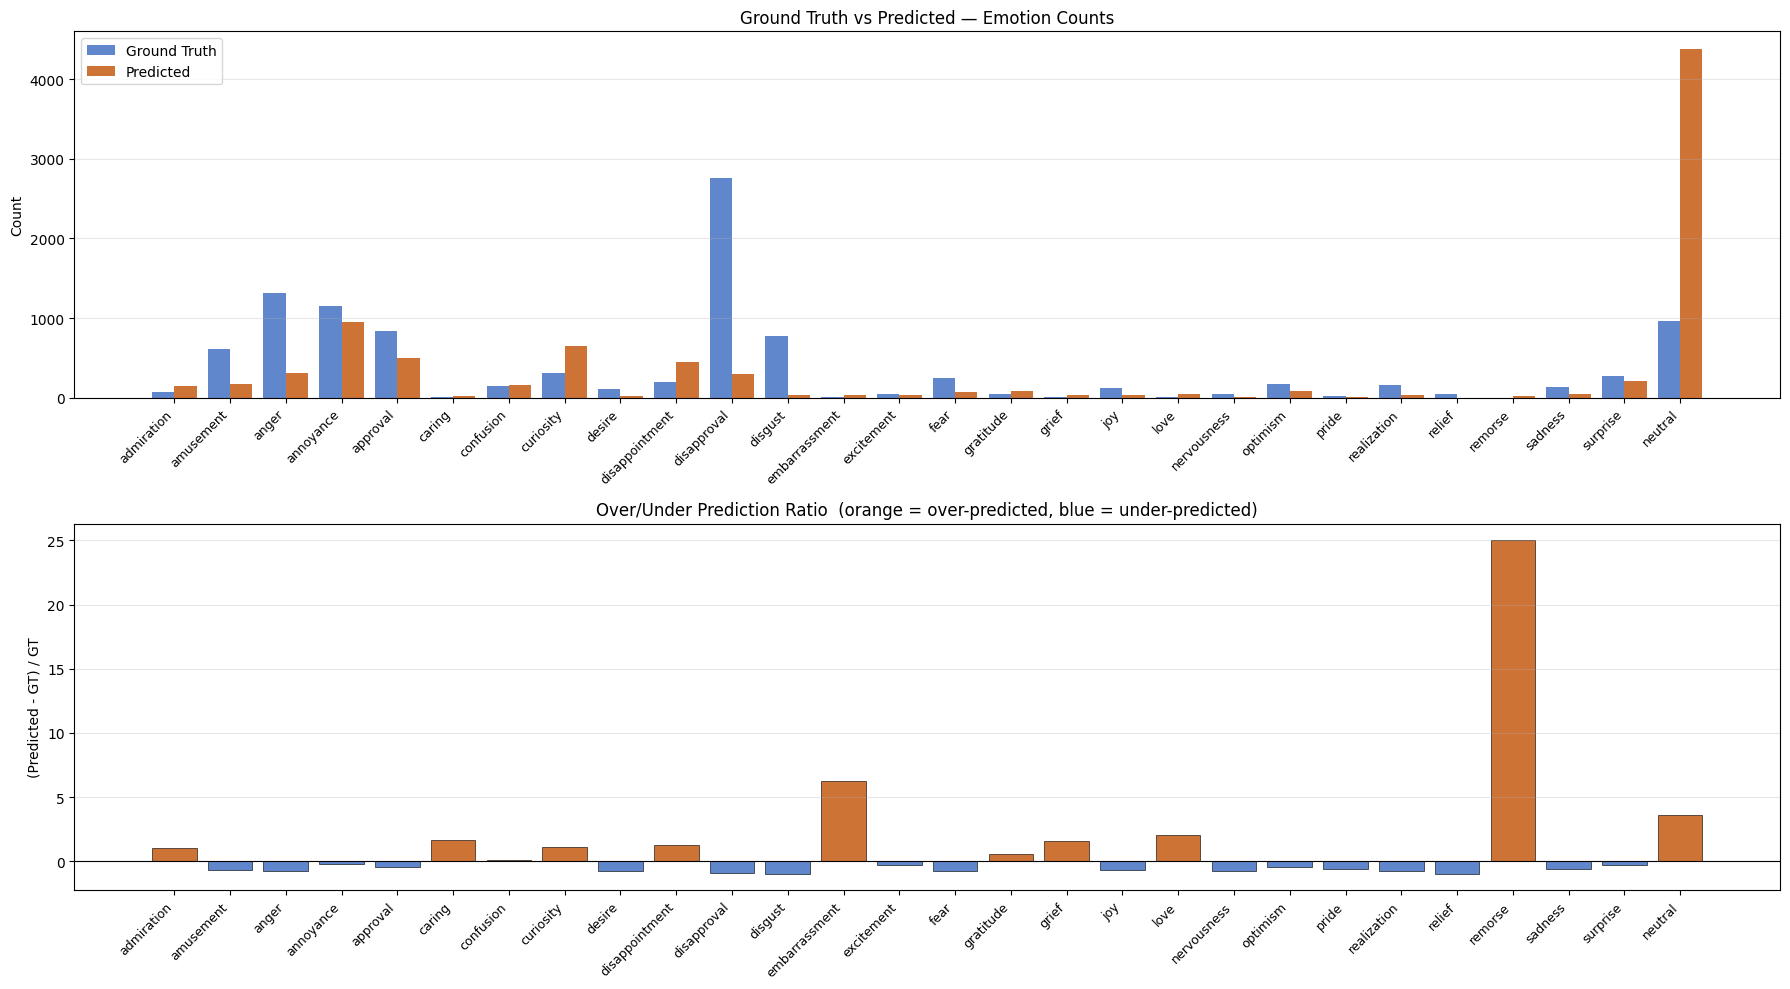

In [11]:
gt_counts   = Counter(e for emotions in test_df['ground_truth_emotions']   for e in emotions)
pred_counts = Counter(e for emotions in test_df['model_predicted_emotions'] for e in emotions)

gt_vals   = np.array([gt_counts.get(e, 0)   for e in sentimentLabels])
pred_vals = np.array([pred_counts.get(e, 0) for e in sentimentLabels])

x     = np.arange(len(sentimentLabels))
width = 0.4

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))

# top: raw counts
b1 = ax1.bar(x - width/2, gt_vals,   width, label='Ground Truth', color='#4472C4', alpha=0.85)
b2 = ax1.bar(x + width/2, pred_vals, width, label='Predicted',    color='#C55A11', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(sentimentLabels, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Count')
ax1.set_title('Ground Truth vs Predicted — Emotion Counts')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# bottom: over/under prediction ratio  (pred - gt) / max(gt, 1)
ratio = (pred_vals - gt_vals) / np.maximum(gt_vals, 1)
colors = ['#C55A11' if r > 0 else '#4472C4' for r in ratio]
ax2.bar(x, ratio, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(sentimentLabels, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('(Predicted - GT) / GT')
ax2.set_title('Over/Under Prediction Ratio  (orange = over-predicted, blue = under-predicted)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

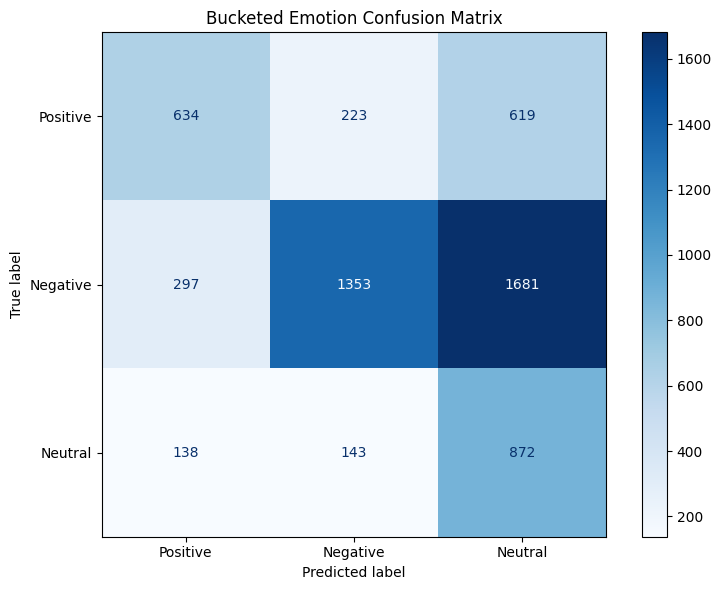

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sentimentMap = {
    "positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                 "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                 "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
    "neutral":  ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

pos_indices = [sentimentLabels.index(e) for e in sentimentMap['positive'] if e in sentimentLabels]
neg_indices = [sentimentLabels.index(e) for e in sentimentMap['negative'] if e in sentimentLabels]
neu_indices = [sentimentLabels.index(e) for e in sentimentMap['neutral']  if e in sentimentLabels]

def get_bucket_preds(matrix):
    buckets = []
    for row in matrix:
        scores = [np.sum(row[pos_indices]), np.sum(row[neg_indices]), np.sum(row[neu_indices])]
        buckets.append(np.argmax(scores))
    return buckets

y_true_buckets = get_bucket_preds(y_true)
y_pred_buckets = get_bucket_preds(y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_buckets, y_pred_buckets),
    display_labels=['Positive', 'Negative', 'Neutral']
).plot(cmap='Blues', ax=ax)
plt.title("Bucketed Emotion Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_buckets, y_pred_buckets,
    target_names=['Positive', 'Negative', 'Neutral'],
    zero_division=0
))

              precision    recall  f1-score   support

    Positive       0.59      0.43      0.50      1476
    Negative       0.79      0.41      0.54      3331
     Neutral       0.27      0.76      0.40      1153

    accuracy                           0.48      5960
   macro avg       0.55      0.53      0.48      5960
weighted avg       0.64      0.48      0.50      5960



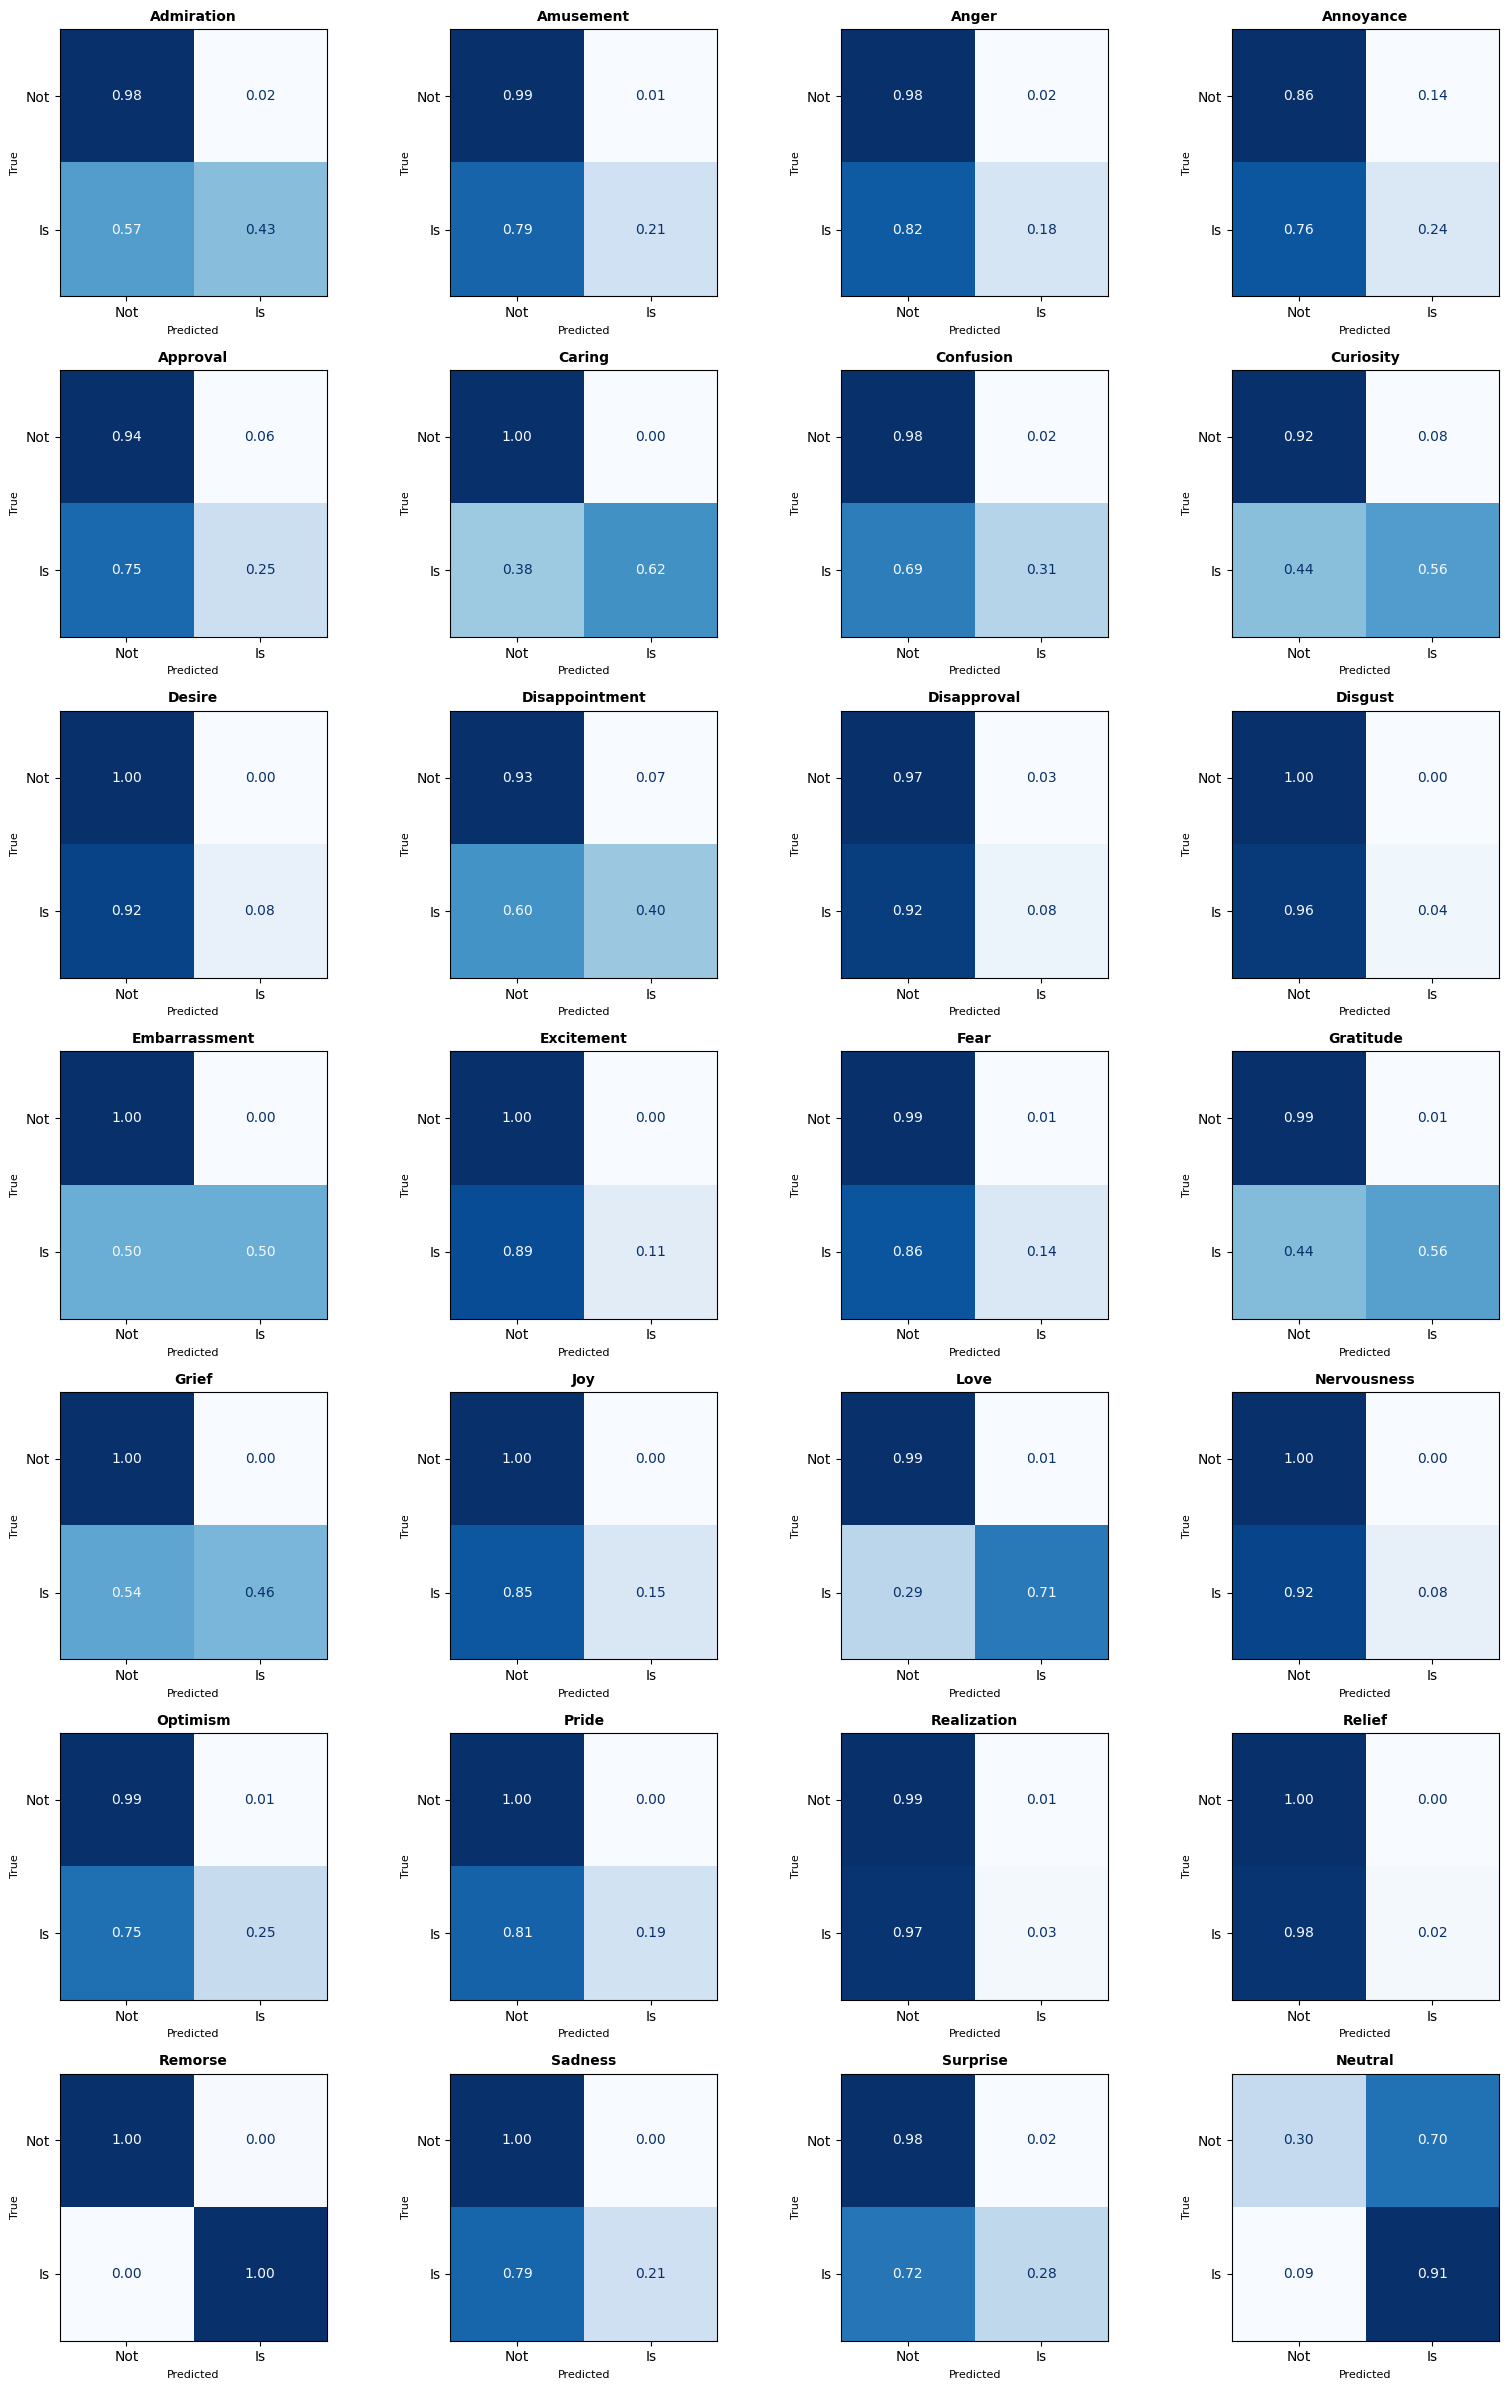

In [14]:
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.ravel()

for i, (name, matrix) in enumerate(zip(sentimentLabels, mcm)):
    row_sums = matrix.sum(axis=1)
    normed = np.divide(
        matrix.astype('float'), row_sums[:, np.newaxis],
        out=np.zeros_like(matrix, dtype=float),
        where=row_sums[:, np.newaxis] != 0
    )
    ConfusionMatrixDisplay(confusion_matrix=normed, display_labels=['Not', 'Is']).plot(
        ax=axes[i], cmap='Blues', colorbar=False, values_format='.2f'
    )
    axes[i].set_title(name.capitalize(), fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('True', fontsize=8)

plt.tight_layout()
plt.show()

accuracy:          0.5418
balanced accuracy: 0.5489

              precision    recall  f1-score   support

Conservative       0.61      0.49      0.54      3321
     Liberal       0.49      0.61      0.54      2639

    accuracy                           0.54      5960
   macro avg       0.55      0.55      0.54      5960
weighted avg       0.56      0.54      0.54      5960



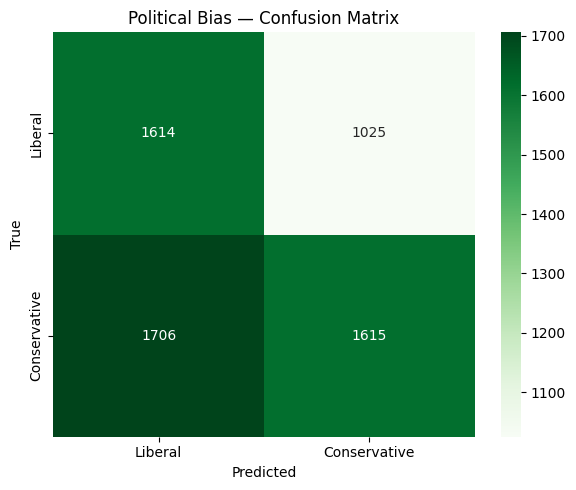

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

y_true_political = test_df['subreddit'].values
y_pred_political = test_df['model_predicted_political'].values

political_accuracy = accuracy_score(y_true_political, y_pred_political)
balanced_accuracy  = balanced_accuracy_score(y_true_political, y_pred_political)

print(f"accuracy:          {political_accuracy:.4f}")
print(f"balanced accuracy: {balanced_accuracy:.4f}\n")
print(classification_report(y_true_political, y_pred_political, zero_division=0))

cm_political = confusion_matrix(y_true_political, y_pred_political, labels=['Liberal', 'Conservative'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_political, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Liberal', 'Conservative'],
            yticklabels=['Liberal', 'Conservative'])
plt.title("Political Bias — Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

model         total (s)   ms/sample
------------------------------------
sentiment        34.304       5.756
political        62.809      10.538
topic            12.497       2.097
combined        109.610      18.391

throughput: 54.4 samples/sec


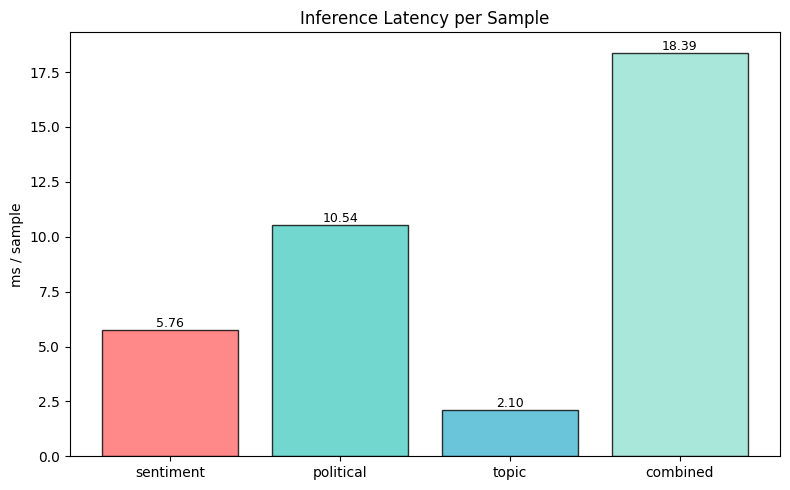

In [16]:
total_latency = sum(v['total'] for v in latency_metrics.values())
total_latency_per_sample = total_latency / len(test_df) * 1000

print(f"{'model':<12} {'total (s)':>10}  {'ms/sample':>10}")
print("-" * 36)
for name, m in latency_metrics.items():
    print(f"{name:<12} {m['total']:>10.3f}  {m['per_sample']:>10.3f}")
print(f"{'combined':<12} {total_latency:>10.3f}  {total_latency_per_sample:>10.3f}")
print(f"\nthroughput: {len(test_df)/total_latency:.1f} samples/sec")

fig, ax = plt.subplots(figsize=(8, 5))
labels = list(latency_metrics.keys()) + ['combined']
values = [v['per_sample'] for v in latency_metrics.values()] + [total_latency_per_sample]
ax.bar(labels, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'], alpha=0.8, edgecolor='black')
ax.set_ylabel('ms / sample')
ax.set_title('Inference Latency per Sample')
for bar, val in zip(ax.patches, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score
from collections import Counter

if 'predicted_topic' in test_df.columns and test_df['predicted_topic'].notna().any():
    mask = test_df['predicted_topic'].notna()
    y_true_topics = test_df.loc[mask, 'predicted_topic'].values
    y_pred_topics = test_df.loc[mask, 'model_predicted_topic'].values
    topic_accuracy = accuracy_score(y_true_topics, y_pred_topics)
    print(f"topic accuracy: {topic_accuracy:.4f}  ({mask.sum()} samples with ground truth)")

    gt_counts   = Counter(y_true_topics)
    pred_counts = Counter(y_pred_topics)
    all_topics  = sorted(set(y_true_topics) | set(y_pred_topics))
    print(f"\n{'topic':>6}  {'gt':>6}  {'pred':>6}")
    for t in all_topics:
        print(f"{t:>6}  {gt_counts.get(t,0):>6}  {pred_counts.get(t,0):>6}")
else:
    topic_accuracy = 0.0
    pred_counts = Counter(test_df['model_predicted_topic'])
    print("no ground truth topics — showing predicted distribution")
    print(f"\n{'topic':>6}  {'count':>6}  {'%':>6}")
    for t, c in pred_counts.most_common():
        print(f"{t:>6}  {c:>6}  {c/len(test_df)*100:>5.1f}%")

topic accuracy: 0.3614  (5960 samples with ground truth)

 topic      gt    pred
  -1.0     238       0
   0.0     123     671
   1.0     569     783
   2.0     341      59
   3.0     476     541
   4.0      60     133
   5.0     708     372
   6.0     743     535
   7.0     513     271
   8.0     149     488
   9.0      34      41
  10.0     174     120
  11.0      79      85
  12.0      86      78
  13.0     390     279
  14.0     147     134
  15.0      29      98
  16.0     159     196
  17.0      55      71
  18.0      37     132
  19.0      66      53
  20.0      18      25
  21.0      82     142
  22.0      16     109
  23.0      95     111
  24.0      19      35
  25.0      68     109
  26.0     129      81
  27.0      89      64
  28.0       7      12
  29.0      87      52
  30.0      11      20
  31.0      23      34
  32.0     140      26


In [18]:
summary = pd.DataFrame({
    'model':        ['sentiment', 'political bias', 'topic'],
    'metric':       ['macro f1', 'accuracy', 'accuracy'],
    'score':        [round(sentiment_macro_f1, 4), round(political_accuracy, 4), round(topic_accuracy, 4)],
    'architecture': ['GoEmotionsFinalModel (RoBERTa)', 'politicalBiasBERT (fine-tuned)', 'TF-IDF + NMF'],
})
print(summary.to_string(index=False))
print(f"\nsentiment — hamming: {hamming:.4f}  exact match: {exact_match:.4f}")

         model   metric  score                   architecture
     sentiment macro f1 0.2381 GoEmotionsFinalModel (RoBERTa)
political bias accuracy 0.5418 politicalBiasBERT (fine-tuned)
         topic accuracy 0.3614                   TF-IDF + NMF

sentiment — hamming: 0.0857  exact match: 0.1138


emotion_bucket             Negative  Neutral  Positive
model_predicted_political                             
Conservative                    816     1384       440
Liberal                         969     1745       606


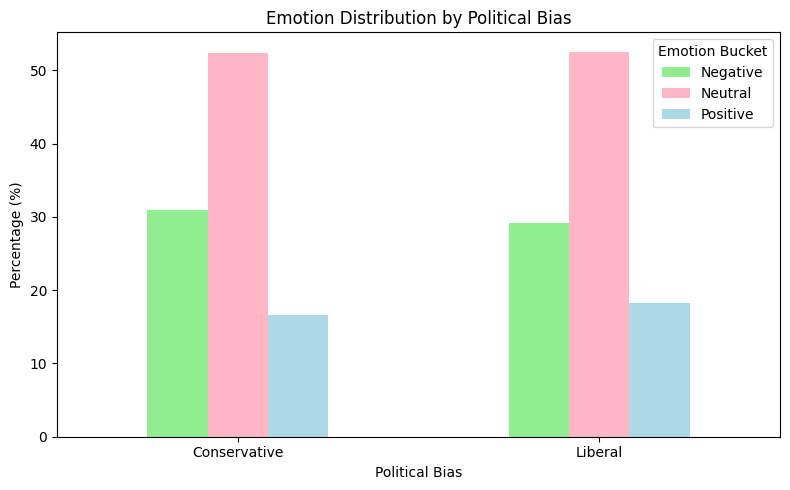

In [19]:
def get_emotion_bucket_label(emotions):
    pos = set(sentimentMap['positive'])
    neg = set(sentimentMap['negative'])
    pos_count = sum(1 for e in emotions if e in pos)
    neg_count = sum(1 for e in emotions if e in neg)
    if pos_count > neg_count:   return 'Positive'
    elif neg_count > pos_count: return 'Negative'
    else:                       return 'Neutral'

test_df['emotion_bucket'] = test_df['model_predicted_emotions'].apply(get_emotion_bucket_label)

crosstab = pd.crosstab(test_df['model_predicted_political'], test_df['emotion_bucket'])
print(crosstab)

crosstab_pct = pd.crosstab(
    test_df['model_predicted_political'], test_df['emotion_bucket'], normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, 5))
crosstab_pct.plot(kind='bar', ax=ax, color=['#90EE90', '#FFB6C6', '#ADD8E6'])
plt.title("Emotion Distribution by Political Bias")
plt.xlabel("Political Bias")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Emotion Bucket")
plt.tight_layout()
plt.show()

Liberal:
  ELECTIONS: Campaigns & Primaries: 486
  IDEOLOGY: Extremism & Global Conflict: 335
  POLITICS: Legislative Branch & Governance: 323
  INVESTIGATION: Government Investigations: 312
  FOREIGN POLICY: Russia-Ukraine Conflict: 263

Conservative:
  INVESTIGATION: Government Investigations: 359
  ELECTIONS: Campaigns & Primaries: 297
  FOREIGN POLICY: Russia-Ukraine Conflict: 272
  POLITICS: Legislative Branch & Governance: 218
  POLITICS: Ethical Misconduct & Accountability: 192



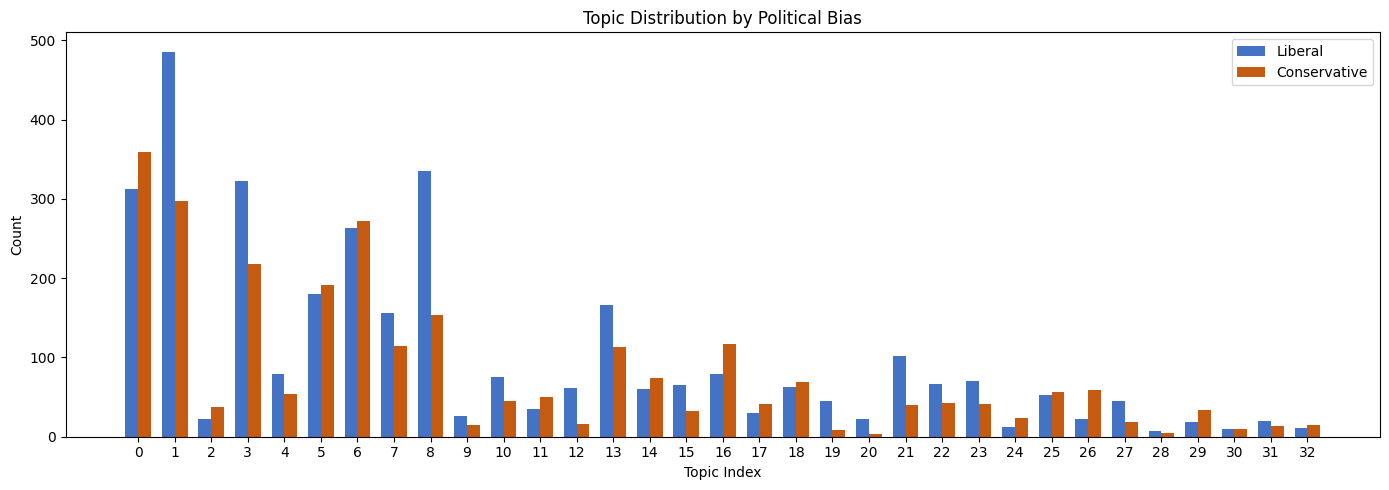

In [20]:
TOPICS_LIST = topic_labels  # loaded from bertopic_model_data.pkl

for bias in ['Liberal', 'Conservative']:
    top5 = test_df[test_df['model_predicted_political'] == bias]['model_predicted_topic'].value_counts().head(5)
    print(f"{bias}:")
    for idx, count in top5.items():
        print(f"  {TOPICS_LIST.get(idx, str(idx))}: {count}")
    print()

liberal_topics      = test_df[test_df['model_predicted_political'] == 'Liberal']['model_predicted_topic'].value_counts()
conservative_topics = test_df[test_df['model_predicted_political'] == 'Conservative']['model_predicted_topic'].value_counts()

all_t = sorted(set(liberal_topics.index) | set(conservative_topics.index))
x = np.arange(len(all_t))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, [liberal_topics.get(t, 0) for t in all_t],      width, label='Liberal',      color='#4472C4')
ax.bar(x + width/2, [conservative_topics.get(t, 0) for t in all_t], width, label='Conservative', color='#C55A11')
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in all_t])
ax.set_xlabel('Topic Index')
ax.set_ylabel('Count')
ax.set_title('Topic Distribution by Political Bias')
ax.legend()
plt.tight_layout()
plt.show()

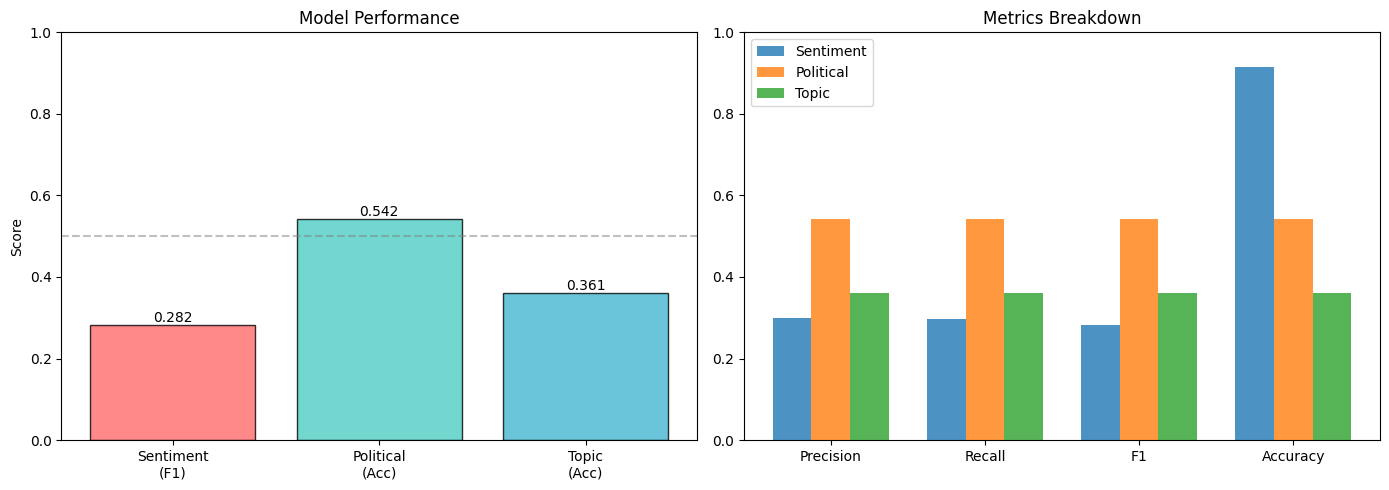

In [21]:
scores = [f1, political_accuracy, topic_accuracy]
model_names = ['Sentiment\n(F1)', 'Political\n(Acc)', 'Topic\n(Acc)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(model_names, scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
ax1.set_ylim(0, 1.0)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Score')
ax1.set_title('Model Performance')
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{score:.3f}' if score > 0 else 'N/A',
             ha='center', va='bottom', fontsize=10)

metrics_vals = {
    'Sentiment': [precision, recall, f1, 1 - hamming],
    'Political':  [political_accuracy] * 4,
    'Topic':      [topic_accuracy] * 4,
}
x_pos = np.arange(4)
width = 0.25
for j, (label, vals) in enumerate(metrics_vals.items()):
    ax2.bar(x_pos + (j - 1) * width, vals, width, label=label, alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Precision', 'Recall', 'F1', 'Accuracy'])
ax2.set_ylim(0, 1.0)
ax2.set_title('Metrics Breakdown')
ax2.legend()

plt.tight_layout()
plt.show()

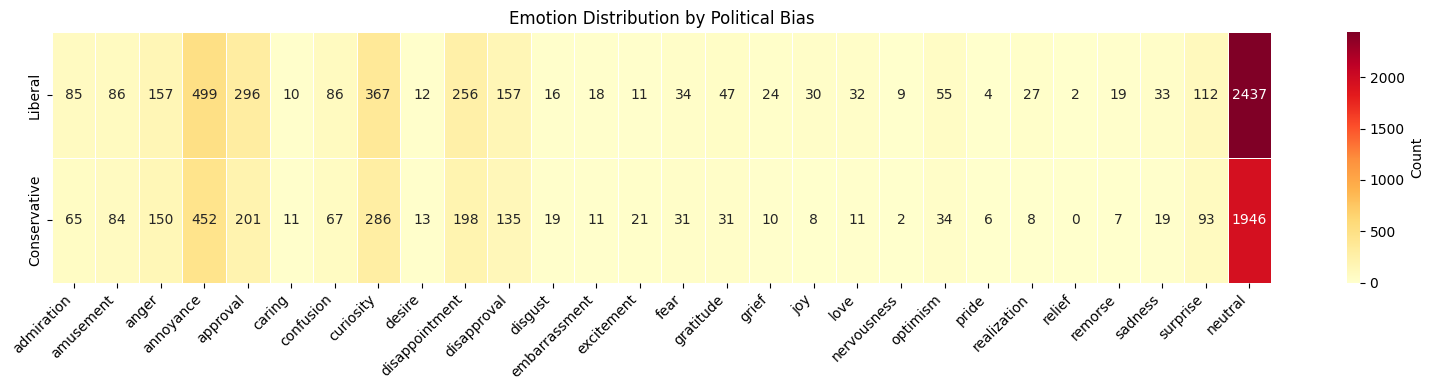

Liberal: neutral (2437), annoyance (499), curiosity (367), approval (296), disappointment (256)
Conservative: neutral (1946), annoyance (452), curiosity (286), approval (201), disappointment (198)


In [22]:
emotion_rows = []
for bias in ['Liberal', 'Conservative']:
    counts = Counter(
        e for emotions in test_df[test_df['model_predicted_political'] == bias]['model_predicted_emotions']
        for e in emotions
    )
    emotion_rows.append([counts.get(e, 0) for e in sentimentLabels])

heatmap_df = pd.DataFrame(emotion_rows, index=['Liberal', 'Conservative'], columns=sentimentLabels)
active = [c for c in heatmap_df.columns if heatmap_df[c].sum() > 0]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heatmap_df[active], annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Count'}, ax=ax)
plt.title('Emotion Distribution by Political Bias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

for bias in ['Liberal', 'Conservative']:
    counts = Counter(
        e for emotions in test_df[test_df['model_predicted_political'] == bias]['model_predicted_emotions']
        for e in emotions
    )
    print(f"{bias}: " + ", ".join(f"{e} ({c})" for e, c in counts.most_common(5)))

In [23]:
analysis_df = test_df[['comment_body', 'subreddit', 'model_predicted_emotions',
                        'model_predicted_political', 'model_predicted_topic']].copy()
analysis_df['topic_name']       = analysis_df['model_predicted_topic'].apply(lambda x: TOPICS_LIST.get(x, str(x)))
analysis_df['emotion_bucket']   = analysis_df['model_predicted_emotions'].apply(get_emotion_bucket_label)
analysis_df['political_correct'] = analysis_df['subreddit'] == analysis_df['model_predicted_political']

correct = analysis_df['political_correct'].sum()
total   = len(analysis_df)
print(f"political accuracy: {correct}/{total} ({correct/total*100:.1f}%)")
print()

# show a sample of misclassified political predictions
wrong = analysis_df[~analysis_df['political_correct']].head(5)
for _, row in wrong.iterrows():
    print(f"[{row['subreddit']} -> {row['model_predicted_political']}] {row['comment_body'][:90]}")
    print(f"  emotions: {row['model_predicted_emotions']}  topic: {row['topic_name']}\n")

political accuracy: 3229/5960 (54.2%)

[Liberal -> Conservative] Fuck ICE.
  emotions: ['anger', 'neutral']  topic: INVESTIGATION: Government Investigations

[Liberal -> Conservative] Here’s a better article from Daily Beast including quotes that Trump is looking at Markway
  emotions: ['neutral']  topic: POLITICS: Legislative Branch & Governance

[Liberal -> Conservative] They’re all puppets, it doesn’t actually matter who is in charge
  emotions: ['neutral']  topic: POLITICS: Ethical Misconduct & Accountability

[Liberal -> Conservative] One down, many more to go!
  emotions: ['neutral']  topic: POLITICS: Legislative Branch & Governance

[Liberal -> Conservative] And yet the files aren’t out, and aren’t gonna be
  emotions: ['neutral']  topic: INVESTIGATION: Government Investigations



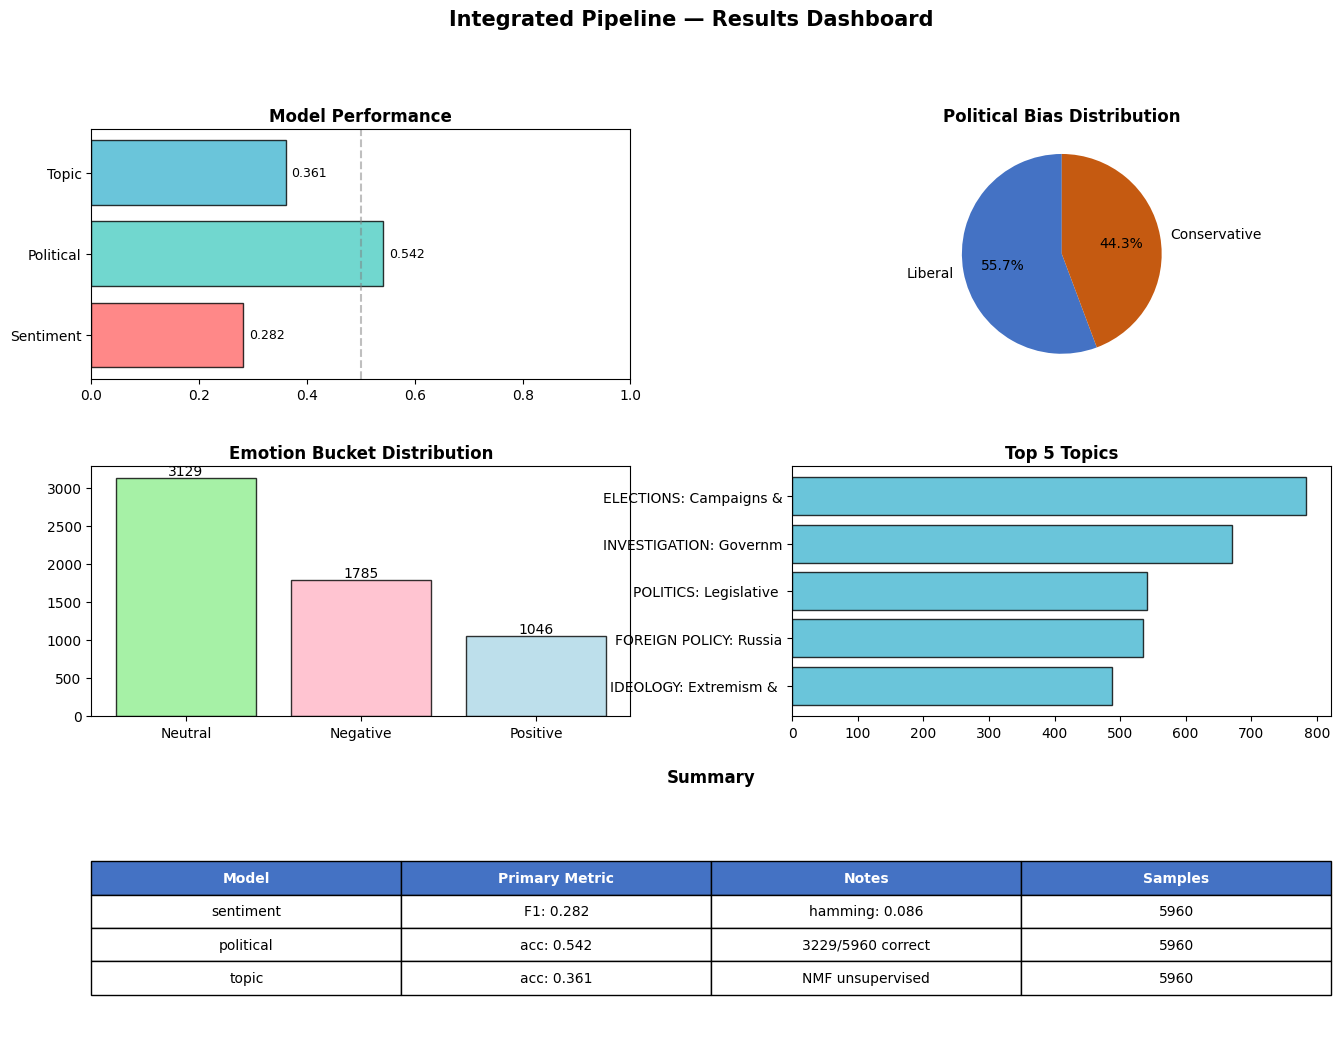

In [24]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# model performance
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(['Sentiment', 'Political', 'Topic'], scores,
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
ax1.set_xlim(0, 1.0)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Model Performance', fontweight='bold')
for bar, score in zip(bars, scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}' if score > 0 else 'N/A', va='center', fontsize=9)

# political distribution
ax2 = fig.add_subplot(gs[0, 1])
pol_counts = test_df['model_predicted_political'].value_counts()
ax2.pie(pol_counts.values, labels=pol_counts.index, autopct='%1.1f%%',
        colors=['#4472C4', '#C55A11'], startangle=90)
ax2.set_title('Political Bias Distribution', fontweight='bold')

# emotion buckets
ax3 = fig.add_subplot(gs[1, 0])
bucket_counts = analysis_df['emotion_bucket'].value_counts()
ax3.bar(bucket_counts.index, bucket_counts.values,
        color=['#90EE90', '#FFB6C6', '#ADD8E6'], alpha=0.8, edgecolor='black')
ax3.set_title('Emotion Bucket Distribution', fontweight='bold')
for i, (b, c) in enumerate(bucket_counts.items()):
    ax3.text(i, c, str(c), ha='center', va='bottom')

# top 5 topics
ax4 = fig.add_subplot(gs[1, 1])
top_topics = test_df['model_predicted_topic'].value_counts().head(5)
names = [TOPICS_LIST.get(t, str(t))[:22] for t in top_topics.index]
ax4.barh(range(len(top_topics)), top_topics.values, color='#45B7D1', alpha=0.8, edgecolor='black')
ax4.set_yticks(range(len(top_topics)))
ax4.set_yticklabels(names)
ax4.invert_yaxis()
ax4.set_title('Top 5 Topics', fontweight='bold')

# summary table
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
table_data = [
    ['sentiment',  f'F1: {f1:.3f}',                 f'hamming: {hamming:.3f}',           str(len(test_df))],
    ['political',  f'acc: {political_accuracy:.3f}', f'{correct}/{total} correct',         str(len(test_df))],
    ['topic',      f'acc: {topic_accuracy:.3f}',     'NMF unsupervised',                   str(len(test_df))],
]
tbl = ax5.table(cellText=table_data, colLabels=['Model', 'Primary Metric', 'Notes', 'Samples'],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2)
for j in range(4):
    tbl[(0, j)].set_facecolor('#4472C4')
    tbl[(0, j)].set_text_props(weight='bold', color='white')
ax5.set_title('Summary', fontweight='bold', pad=15)

fig.suptitle('Integrated Pipeline — Results Dashboard', fontsize=15, fontweight='bold')
plt.show()

In [25]:
print("sentiment")
print(f"  macro f1:    {sentiment_macro_f1:.4f}")
print(f"  hamming:     {hamming:.4f}")
print(f"  exact match: {exact_match:.4f}")
print()
print("political bias")
print(f"  accuracy:          {political_accuracy:.4f}")
print(f"  balanced accuracy: {balanced_accuracy:.4f}")
print()
print("topic")
print(f"  accuracy: {topic_accuracy:.4f}" if topic_accuracy > 0 else "  accuracy: N/A (unsupervised)")
print()
print("latency")
for name, m in latency_metrics.items():
    print(f"  {name}: {m['per_sample']:.2f} ms/sample")
print(f"  combined: {total_latency_per_sample:.2f} ms/sample  ({len(test_df)/total_latency:.0f} samples/sec)")
print()
print(f"n={len(test_df)}  liberal={( test_df['subreddit']=='Liberal').sum()}  conservative={(test_df['subreddit']=='Conservative').sum()}")

sentiment
  macro f1:    0.2381
  hamming:     0.0857
  exact match: 0.1138

political bias
  accuracy:          0.5418
  balanced accuracy: 0.5489

topic
  accuracy: 0.3614

latency
  sentiment: 5.76 ms/sample
  political: 10.54 ms/sample
  topic: 2.10 ms/sample
  combined: 18.39 ms/sample  (54 samples/sec)

n=5960  liberal=2639  conservative=3321


In [26]:
# combined scoring using partial credit system
# 0 correct = 0%, 1 correct = 33.33%, 2 correct = 66.67%, 3 correct = 100%
scoreMap = {0: 0, 1: 33.33, 2: 66.67, 3: 100}

sentCorrect  = np.array(y_true_buckets) == np.array(y_pred_buckets)
polCorrect   = y_true_political == y_pred_political
topicCorrect = y_true_topics == y_pred_topics

# count how many models got each sample right
numCorrect = sentCorrect.astype(int) + polCorrect.astype(int) + topicCorrect.astype(int)

# apply partial credit scores per sample then average
sampleScores = [scoreMap[n] for n in numCorrect]
combinedScore = np.mean(sampleScores)

print(f"combined partial credit score: {combinedScore:.2f}%")

combined partial credit score: 46.10%
